# FinCrime Transaction Monitor — Exploratory Data Analysis

**Objective:** understand transaction patterns, class imbalance, and signals that
differentiate fraudulent from legitimate activity, to inform feature engineering.

**Dataset:** 100,000 synthetic transactions from 5,000 users over 90 days,
with ~2% fraud prevalence and four injected typologies.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

tx = pd.read_csv('../data/transactions.csv', parse_dates=['timestamp'])
users = pd.read_csv('../data/users.csv')

print(f"Transactions: {len(tx):,}")
print(f"Users: {len(users):,}")
print(f"Date range: {tx['timestamp'].min()} → {tx['timestamp'].max()}")
tx.head()

Transactions: 100,000
Users: 5,000
Date range: 2025-01-01 00:01:19 → 2025-03-30 23:59:15


,transaction_id,user_id,timestamp,amount_usd,country,merchant_category,channel,is_fraud
0,T0000000,U02901,2025-01-01 00:01:19,37.38,CO,gambling,card_not_present,0
1,T0000001,U03694,2025-01-01 00:04:59,40.91,CO,atm_withdrawal,online,0
2,T0000002,U04996,2025-01-01 00:07:06,70.65,CO,atm_withdrawal,mobile_app,0
3,T0000003,U03702,2025-01-01 00:07:12,7.21,MX,travel,online,0
4,T0000004,U03353,2025-01-01 00:08:08,53.87,CO,crypto_exchange,card_present,0


## 1. Class imbalance

Fraud detection is fundamentally an imbalanced-class problem. This shapes every
downstream decision: evaluation metrics (precision/recall over accuracy),
model choice, and whether to use class weights or resampling.

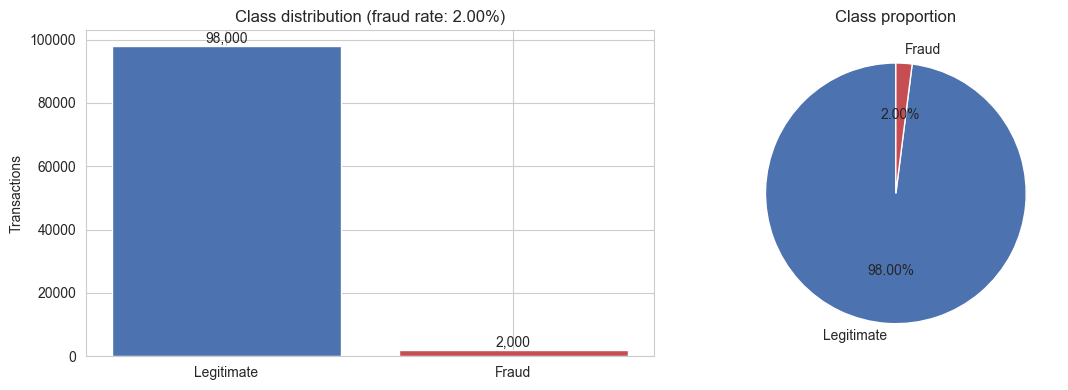


📌 Insight: 2.00% fraud rate means accuracy is a misleading metric.
    A model predicting 'always legitimate' would score 98.00% accuracy.


In [7]:
fraud_counts = tx['is_fraud'].value_counts()
fraud_rate = tx['is_fraud'].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['#4C72B0', '#C44E52'])
ax[0].set_title(f'Class distribution (fraud rate: {fraud_rate:.2%})')
ax[0].set_ylabel('Transactions')
for i, v in enumerate(fraud_counts.values):
    ax[0].text(i, v, f'{v:,}', ha='center', va='bottom')

ax[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
          autopct='%1.2f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
ax[1].set_title('Class proportion')
plt.tight_layout()
plt.show()

print(f"\n📌 Insight: {fraud_rate:.2%} fraud rate means accuracy is a misleading metric.")
print(f"    A model predicting 'always legitimate' would score {1-fraud_rate:.2%} accuracy.")

## 2. Transaction amount distribution

Amount is expected to be a strong signal — fraud typologies like "high-value
anomaly" inject unusually large transactions. We use log-scale to handle the
heavy right tail.

C:\Users\Camila\AppData\Local\Temp\ipykernel_24300\4107542379.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Legitimate', 'Fraud'])


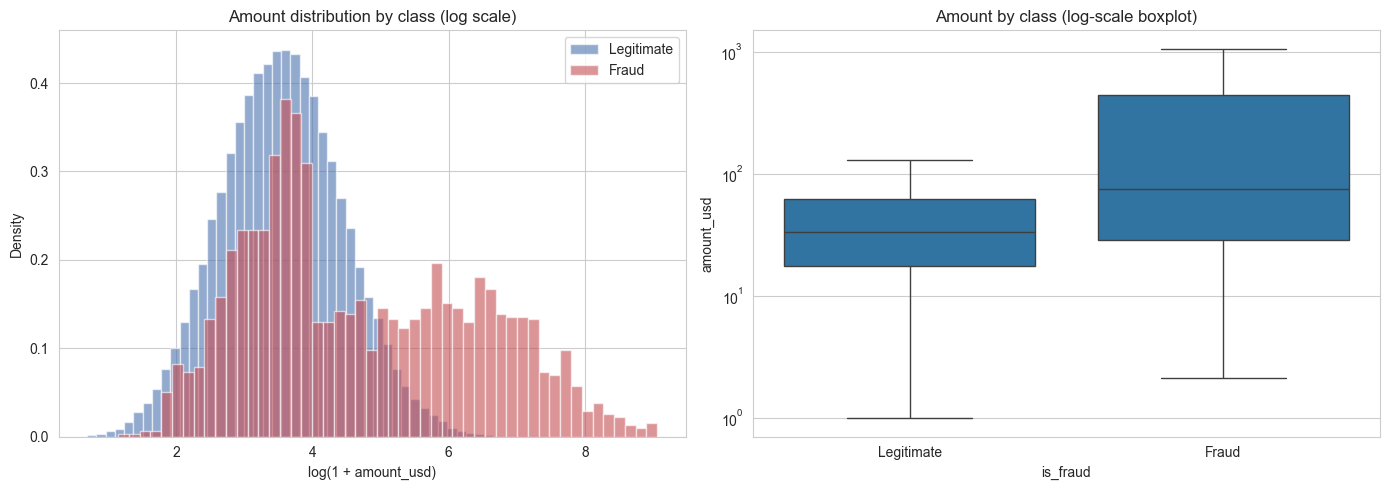


📊 Amount statistics by class:
            mean    50%     75%      max
is_fraud                                
0          51.78  33.54   62.54  1754.12
1         429.98  75.54  442.83  8613.79


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(np.log1p(tx[tx['is_fraud']==0]['amount_usd']), bins=50,
           alpha=0.6, label='Legitimate', color='#4C72B0', density=True)
ax[0].hist(np.log1p(tx[tx['is_fraud']==1]['amount_usd']), bins=50,
           alpha=0.6, label='Fraud', color='#C44E52', density=True)
ax[0].set_xlabel('log(1 + amount_usd)')
ax[0].set_ylabel('Density')
ax[0].set_title('Amount distribution by class (log scale)')
ax[0].legend()

sns.boxplot(data=tx, x='is_fraud', y='amount_usd', ax=ax[1], showfliers=False)
ax[1].set_yscale('log')
ax[1].set_xticklabels(['Legitimate', 'Fraud'])
ax[1].set_title('Amount by class (log-scale boxplot)')
plt.tight_layout()
plt.show()

print("\n📊 Amount statistics by class:")
print(tx.groupby('is_fraud')['amount_usd'].describe()[['mean', '50%', '75%', 'max']].round(2))

## 3. Fraud rate by categorical features

Which categories concentrate fraud? This identifies risk segments that will
become features (e.g., high-risk MCC flag, high-risk country flag).

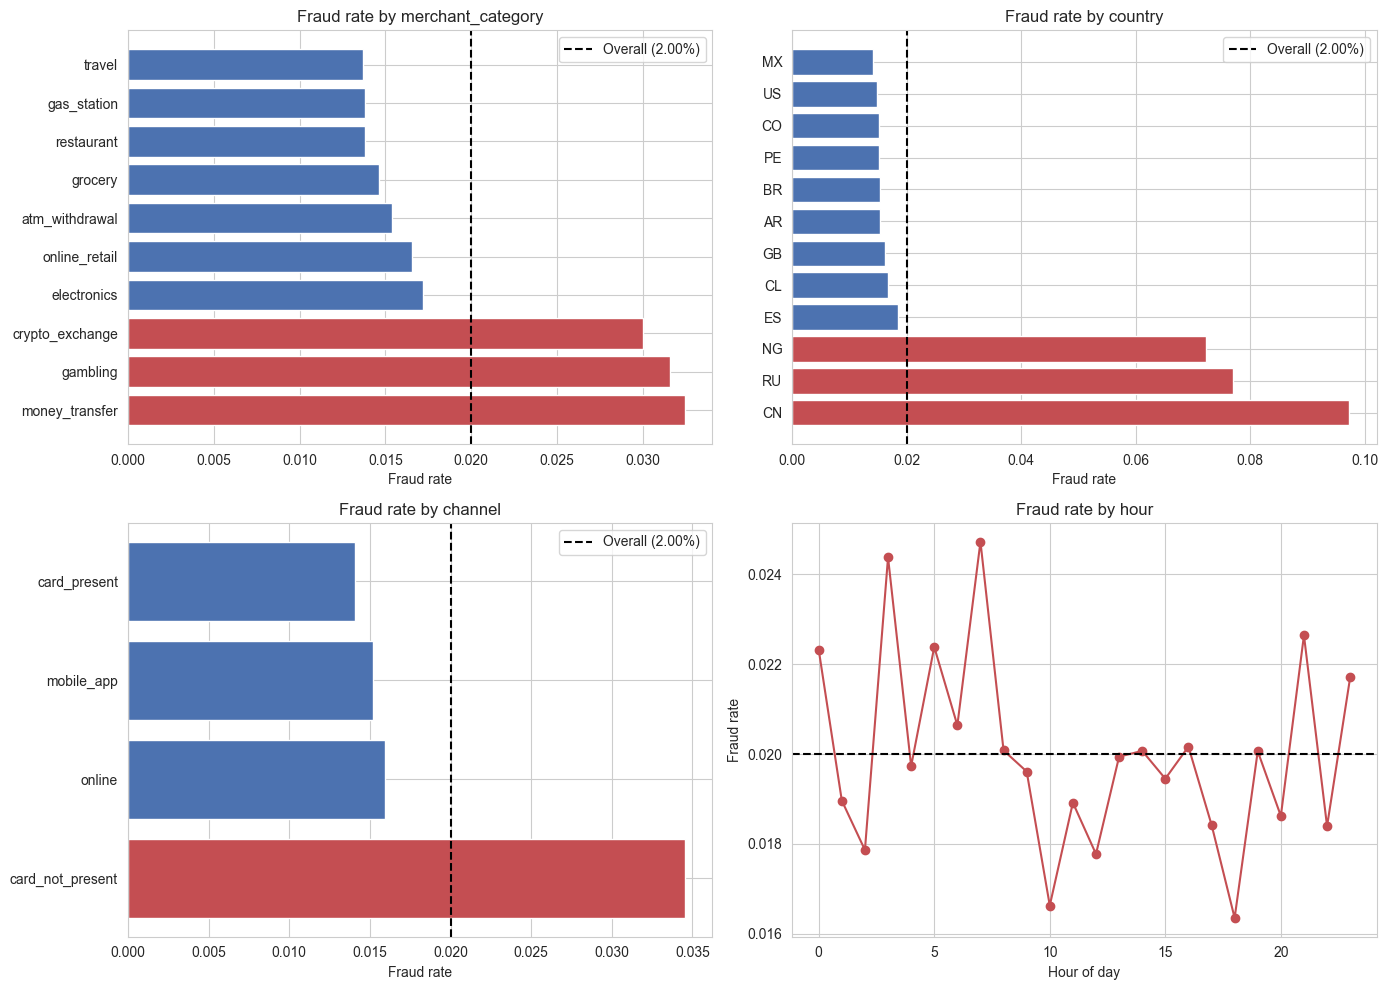

In [9]:
def plot_fraud_rate(df, col, ax, top_n=None):
    rate = df.groupby(col)['is_fraud'].agg(['mean', 'count']).reset_index()
    rate.columns = [col, 'fraud_rate', 'volume']
    rate = rate.sort_values('fraud_rate', ascending=False)
    if top_n:
        rate = rate.head(top_n)
    colors = ['#C44E52' if r > df['is_fraud'].mean() * 1.5 else '#4C72B0'
              for r in rate['fraud_rate']]
    ax.barh(rate[col], rate['fraud_rate'], color=colors)
    ax.axvline(df['is_fraud'].mean(), color='black', linestyle='--',
               label=f'Overall ({df["is_fraud"].mean():.2%})')
    ax.set_xlabel('Fraud rate')
    ax.set_title(f'Fraud rate by {col}')
    ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_fraud_rate(tx, 'merchant_category', axes[0, 0])
plot_fraud_rate(tx, 'country', axes[0, 1])
plot_fraud_rate(tx, 'channel', axes[1, 0])

# Hour of day
tx['hour'] = tx['timestamp'].dt.hour
hourly_fraud = tx.groupby('hour')['is_fraud'].mean()
axes[1, 1].plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='#C44E52')
axes[1, 1].axhline(tx['is_fraud'].mean(), color='black', linestyle='--')
axes[1, 1].set_xlabel('Hour of day')
axes[1, 1].set_ylabel('Fraud rate')
axes[1, 1].set_title('Fraud rate by hour')

plt.tight_layout()
plt.show()

## 4. User-level behavior

Fraud often deviates from a user's historical pattern. Looking at transactions
per user and amount variance previews the feature engineering step.

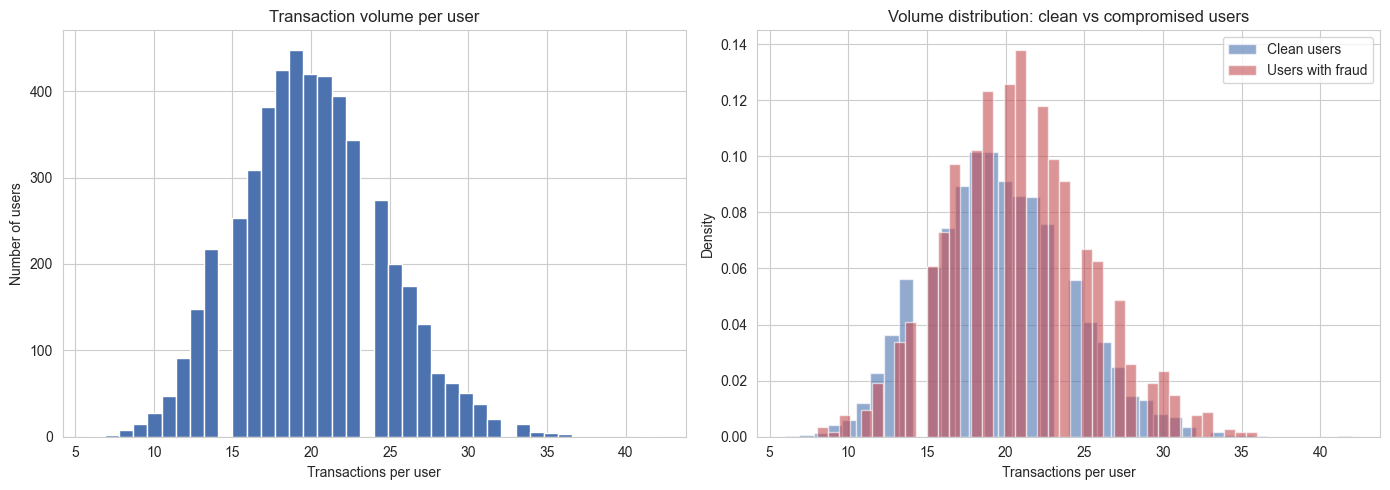


📌 Users with ≥1 fraud: 1,646 (32.92%)


In [10]:
user_stats = tx.groupby('user_id').agg(
    tx_count=('transaction_id', 'count'),
    total_amount=('amount_usd', 'sum'),
    fraud_count=('is_fraud', 'sum'),
).reset_index()
user_stats['has_fraud'] = (user_stats['fraud_count'] > 0).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(user_stats['tx_count'], bins=40, color='#4C72B0', edgecolor='white')
ax[0].set_xlabel('Transactions per user')
ax[0].set_ylabel('Number of users')
ax[0].set_title('Transaction volume per user')

ax[1].hist(user_stats[user_stats['has_fraud']==0]['tx_count'], bins=40,
           alpha=0.6, label='Clean users', color='#4C72B0', density=True)
ax[1].hist(user_stats[user_stats['has_fraud']==1]['tx_count'], bins=40,
           alpha=0.6, label='Users with fraud', color='#C44E52', density=True)
ax[1].set_xlabel('Transactions per user')
ax[1].set_ylabel('Density')
ax[1].set_title('Volume distribution: clean vs compromised users')
ax[1].legend()
plt.tight_layout()
plt.show()

print(f"\n📌 Users with ≥1 fraud: {user_stats['has_fraud'].sum():,} ({user_stats['has_fraud'].mean():.2%})")

## 5. Key takeaways for feature engineering

Based on EDA:

1. **Class imbalance (~2%)** → use precision/recall/PR-AUC, class weights in modeling.
2. **Amount is a strong signal** → build features comparing each tx to user's historical mean.
3. **High-risk MCC and countries concentrate fraud** → binary risk flags as features.
4. **Hour of day matters** → extract hour, flag nighttime transactions.
5. **Channel `card_not_present` over-represented in fraud** → one-hot encode channel.
6. **Velocity patterns expected** → compute rolling transaction counts per user.

These insights drive the 8-10 features in the next notebook.